# ArSL Word Diagnostics — 131-Class Graduation Model

Standalone diagnostics for the **131-class Arabic graduation vocabulary** (words + numbers, no letters).  
Does **not** modify `SLR_Diagnostics.ipynb`, `SLR_Word_Diagnostics.ipynb`, or any training notebook.

| Question | Cell |
|----------|------|
| Do all artifact files exist and are they the right size? | 2 |
| Is the NPZ healthy (shape, blanks, NaNs, class counts)? | 3 |
| How many samples does each vocabulary category have? | 4 |
| What is the model's overall Top-1 / Top-3 / macro-F1? | 5 |
| Full per-class precision / recall / F1 report? | 6 |
| Which classes are worst / best (bar chart)? | 7 |
| Which classes confuse each other (confusion matrix)? | 8 |
| What confidence threshold maximises accuracy/recall? | 9 |
| Deep-dive on a single word (spotlight cell)? | 10 |

In [16]:
# Cell 1 — Imports
import os
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')   # CPU inference — avoids OOM after NPZ load

import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid', palette='muted')

print(f'TensorFlow {tf.__version__} | NumPy {np.__version__}')
print('OK - imports ready')


TensorFlow 2.10.0 | NumPy 1.23.5
OK - imports ready


In [17]:
# Cell 2 — Paths & artifact inventory
DIR = Path(r'M:/Term 10/Grad/SLR Main/Words/ArSL Word (Arabic)')

ARTIFACTS = {
    'grad_npz'      : DIR / 'arsl_graduation_sequences.npz',
    'subset_npz'    : DIR / 'arsl_custom_subset.npz',
    'model_best'    : DIR / 'arsl_custom_best.h5',
    'scaler'        : DIR / 'arsl_custom_scaler.npz',
    'classes_csv'   : DIR / 'arsl_custom_classes.csv',
    'selection_csv' : DIR / 'KARSL-502_GraduationSelection.csv',
    'basicwords_csv': DIR / 'KARSL-502_BasicWords.csv',
    'eval_metrics'  : DIR / 'arsl_custom_eval_metrics.csv',
    'confusion_png' : DIR / 'arsl_custom_confusion_matrix.png',
}

EXPECTED_CLASSES  = 131
EXPECTED_SEQ_LEN  = 48
EXPECTED_FEATURES = 258

def file_row(name, path):
    if not path.exists():
        return {'artifact': name, 'file': path.name, 'status': 'MISSING', 'size_mb': '-'}
    return {'artifact': name, 'file': path.name, 'status': 'OK',
            'size_mb': f'{path.stat().st_size / 1e6:.1f}'}

inv = pd.DataFrame([file_row(k, v) for k, v in ARTIFACTS.items()])
print('=' * 68)
print('ARTIFACT INVENTORY — 131-CLASS GRADUATION MODEL')
print('=' * 68)
print(inv.to_string(index=False))

missing = inv[inv['status'] == 'MISSING']['artifact'].tolist()
if missing:
    print(f'\nMISSING: {missing}')
    print('Run ArSL_Word_Training_CustomWords.ipynb to generate training artifacts.')
else:
    print('\nAll artifacts present.')


ARTIFACT INVENTORY — 131-CLASS GRADUATION MODEL
      artifact                              file status size_mb
      grad_npz     arsl_graduation_sequences.npz     OK   210.5
    subset_npz            arsl_custom_subset.npz     OK   210.5
    model_best               arsl_custom_best.h5     OK    19.9
        scaler            arsl_custom_scaler.npz     OK     0.0
   classes_csv           arsl_custom_classes.csv     OK     0.0
 selection_csv KARSL-502_GraduationSelection.csv     OK     0.0
basicwords_csv          KARSL-502_BasicWords.csv     OK     0.0
  eval_metrics      arsl_custom_eval_metrics.csv     OK     0.0
 confusion_png  arsl_custom_confusion_matrix.png     OK     0.4

All artifacts present.


In [18]:
# Cell 3 — NPZ health audit
import gc

def blank_frame_ratio(X, sample_n=600):
    idx = np.linspace(0, len(X)-1, min(len(X), sample_n), dtype=int)
    return float(np.mean(np.all(X[idx] == 0, axis=-1)))

def audit_npz(path, label, expected_classes=EXPECTED_CLASSES):
    if not path.exists():
        return None
    with np.load(str(path), mmap_mode='r') as d:
        if 'X' not in d.files or 'y' not in d.files:
            return {'label': label, 'error': 'missing X/y keys'}
        X, y = d['X'], d['y']
        n, seq, feat = X.shape
        classes, counts = np.unique(y, return_counts=True)
        blank = blank_frame_ratio(X)
        nan_found = bool(np.isnan(X[:min(n, 1000)]).any())
        return {
            'label': label, 'file': path.name,
            'samples': int(n), 'seq_len': int(seq), 'features': int(feat),
            'classes': int(len(classes)),
            'min/class': int(counts.min()), 'max/class': int(counts.max()),
            'mean/class': round(float(counts.mean()), 1),
            'blank%': f'{blank:.1%}', 'nan': nan_found,
            'size_mb': round(path.stat().st_size / 1e6, 1),
            'seq_ok': seq == EXPECTED_SEQ_LEN,
            'feat_ok': feat == EXPECTED_FEATURES,
            'class_ok': len(classes) == expected_classes,
            '_class_ids': classes, '_counts': counts,
        }

NPZ_SOURCES = [
    ('GRADUATION', ARTIFACTS['grad_npz']),
    ('SUBSET',     ARTIFACTS['subset_npz']),
]

audits, rows = {}, []
for tag, p in NPZ_SOURCES:
    a = audit_npz(p, tag)
    if a is None:
        print(f'[{tag}] not found — skipping')
        continue
    if 'error' in a:
        print(f'[{tag}] ERROR: {a["error"]}')
        continue
    audits[tag] = a
    rows.append({k: v for k, v in a.items() if not k.startswith('_')})

gc.collect()

if rows:
    print('=' * 68)
    print('NPZ HEALTH SUMMARY')
    print('=' * 68)
    print(pd.DataFrame(rows).to_string(index=False))
    print()
    for tag, a in audits.items():
        flags = []
        if not a['seq_ok']:   flags.append(f'seq={a["seq_len"]} (want {EXPECTED_SEQ_LEN})')
        if not a['feat_ok']:  flags.append(f'feat={a["features"]} (want {EXPECTED_FEATURES})')
        if not a['class_ok']: flags.append(f'{a["classes"]}/{EXPECTED_CLASSES} classes')
        if a['nan']:          flags.append('NaN detected in X')
        sym = 'OK' if not flags else 'WARN'
        print(f'[{sym}] {tag}' + (' -- ' + '; '.join(flags) if flags else ' -- healthy'))
else:
    print('No NPZ files found.')

# Pick the primary NPZ for evaluation
PRIMARY_TAG = 'SUBSET' if 'SUBSET' in audits else ('GRADUATION' if 'GRADUATION' in audits else None)
PRIMARY_NPZ = dict(NPZ_SOURCES).get(PRIMARY_TAG)
if PRIMARY_NPZ:
    print(f'\nPrimary for evaluation: {PRIMARY_TAG} -> {PRIMARY_NPZ.name}')


NPZ HEALTH SUMMARY
     label                          file  samples  seq_len  features  classes  min/class  max/class  mean/class blank%   nan  size_mb  seq_ok  feat_ok  class_ok
GRADUATION arsl_graduation_sequences.npz     6616       48       258      131         17        100        50.5  26.7% False    210.5    True     True      True
    SUBSET        arsl_custom_subset.npz     6616       48       258      131         17        100        50.5  26.7% False    210.5    True     True      True

[OK] GRADUATION -- healthy
[OK] SUBSET -- healthy

Primary for evaluation: SUBSET -> arsl_custom_subset.npz


VOCABULARY COVERAGE BY CATEGORY (131 classes)
Classes CSV rows: 131  (expecting 131)
KARSL class_id range in CSV: 2 – 501

Category                Count
------------------------------
number                     31
verb                       17
family                     14
home                       12
emotion                    11
direction                  10
greeting                   10
health                     10
adjective                   6
profession                  6
people                      4
------------------------------
TOTAL                     131


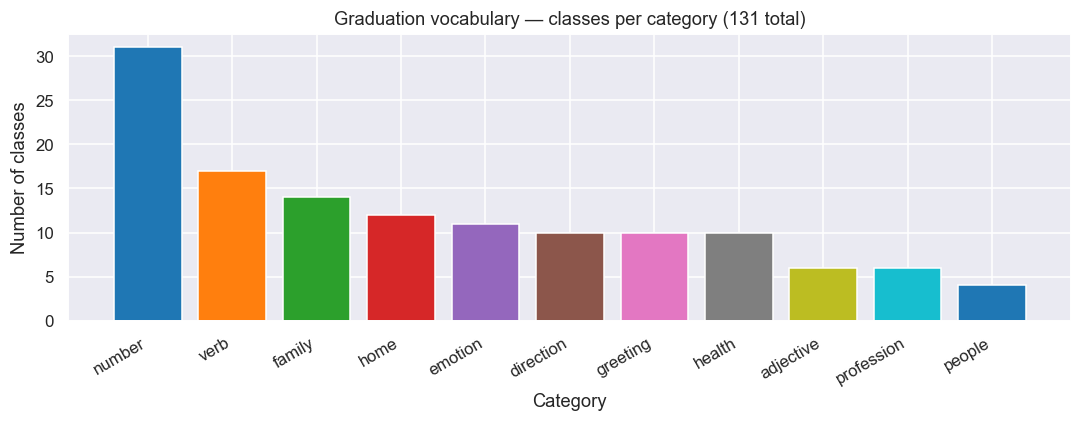


Classes with <30 subset samples (1 classes):
 model_class_index english  subset_samples
                 4       4              17


In [19]:
# Cell 4 — Vocabulary category coverage
print('=' * 68)
print('VOCABULARY COVERAGE BY CATEGORY (131 classes)')
print('=' * 68)

class_df = pd.read_csv(ARTIFACTS['classes_csv'], encoding='utf-8-sig')
bw_df    = pd.read_csv(ARTIFACTS['basicwords_csv']) if ARTIFACTS['basicwords_csv'].exists() else None

idx_to_en     = dict(zip(class_df['model_class_index'], class_df['english'].astype(str)))
idx_to_ar     = dict(zip(class_df['model_class_index'], class_df['arabic'].astype(str)))
# KARSL class_id → model_class_index (needed to remap NPZ y values)
karsl_to_model = dict(zip(class_df['karsl_class_id'].astype(int),
                           class_df['model_class_index'].astype(int)))
print(f'Classes CSV rows: {len(class_df)}  (expecting {EXPECTED_CLASSES})')
print(f'KARSL class_id range in CSV: {class_df["karsl_class_id"].min()} – {class_df["karsl_class_id"].max()}')

# Category breakdown
if bw_df is not None and 'category' in bw_df.columns:
    cat_counts = bw_df.groupby('category')['english'].count().sort_values(ascending=False)
    print()
    print(f'{"Category":<22} {"Count":>6}')
    print('-' * 30)
    for cat, cnt in cat_counts.items():
        print(f'{str(cat):<22} {cnt:>6}')
    print('-' * 30)
    print(f'{"TOTAL":<22} {cat_counts.sum():>6}')

    # Bar chart of category sizes
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(cat_counts.index, cat_counts.values, color=sns.color_palette('tab10', len(cat_counts)))
    ax.set_xlabel('Category')
    ax.set_ylabel('Number of classes')
    ax.set_title('Graduation vocabulary — classes per category (131 total)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No category info — showing full class list:')
    print(class_df[['model_class_index','english','arabic']].to_string(index=False))

# Sample distribution from NPZ
# NOTE: _class_ids in NPZ audit are KARSL class_ids, not model indices — use karsl_to_model to remap.
if 'SUBSET' in audits:
    a = audits['SUBSET']
    counts_map = {}
    for kid, cnt in zip(a['_class_ids'].astype(int), a['_counts']):
        midx = karsl_to_model.get(int(kid))
        if midx is not None:
            counts_map[midx] = int(cnt)
    class_df['subset_samples'] = class_df['model_class_index'].map(lambda i: counts_map.get(int(i), 0))
    low = class_df[class_df['subset_samples'] < 30]
    if len(low):
        print(f'\nClasses with <30 subset samples ({len(low)} classes):')
        print(low[['model_class_index','english','subset_samples']].to_string(index=False))
    else:
        print(f'\nAll classes have >=30 samples in subset. Min={class_df["subset_samples"].min()}')


In [20]:
# Cell 5 — Load model + scaler, run inference on subset
assert PRIMARY_NPZ is not None, 'No NPZ found — run Cell 3 first'

print('Loading model (CPU-only to avoid OOM)...')
model = tf.keras.models.load_model(str(ARTIFACTS['model_best']), compile=False)
SEQ_LEN  = int(model.input_shape[1])
NUM_FEAT = int(model.input_shape[2])
NUM_OUT  = int(model.output_shape[-1])
print(f'Model : {model.name}  params={model.count_params():,}')
print(f'Input : ({SEQ_LEN}, {NUM_FEAT})   Output: {NUM_OUT} classes')

z = np.load(str(ARTIFACTS['scaler']))
scaler_mean  = z['mean'].astype(np.float32)
scaler_scale = z['scale'].astype(np.float32)
print(f'Scaler: {scaler_mean.shape[0]}-dim')

print(f'\nLoading {PRIMARY_TAG} NPZ...')
data  = np.load(str(PRIMARY_NPZ), mmap_mode='r')
X_all = data['X']
y_raw = data['y'].copy()
N     = len(X_all)
print(f'Samples: {N}   Shape: {X_all.shape}')
print(f'y range: {int(y_raw.min())} – {int(y_raw.max())}  (unique: {len(np.unique(y_raw))})')

# If y values are KARSL class_ids (>= NUM_OUT), remap to model indices 0..NUM_OUT-1
if int(y_raw.max()) >= NUM_OUT:
    y_all = np.array([karsl_to_model.get(int(v), -1) for v in y_raw])
    n_bad = int(np.sum(y_all == -1))
    if n_bad:
        print(f'WARNING: {n_bad} samples had KARSL IDs not in graduation CSV and will be excluded.')
        keep  = y_all != -1
        y_all = y_all[keep]
        X_all = X_all[keep]
        N     = len(X_all)
        print(f'Remaining samples after exclusion: {N}')
    print(f'Remapped y: KARSL class_ids -> model indices 0-{int(y_all.max())}')
else:
    y_all = y_raw   # already model indices
    print('y values already in model-index space (0..NUM_OUT-1)')

BATCH = 64
all_proba = np.zeros((N, NUM_OUT), dtype=np.float32)
print(f'Running inference (batch={BATCH})...')
for start in range(0, N, BATCH):
    end   = min(start + BATCH, N)
    batch = X_all[start:end].astype(np.float32)
    batch = (batch - scaler_mean) / scaler_scale
    all_proba[start:end] = model(batch, training=False).numpy()
    if start % 1024 == 0:
        print(f'  {end}/{N}', end='\r')

gc.collect()
y_pred      = np.argmax(all_proba, axis=1)
top3_hits   = np.any(np.argsort(all_proba, axis=1)[:, -3:] == y_all[:, None], axis=1)
overall_top1 = float(np.mean(y_pred == y_all))
overall_top3 = float(np.mean(top3_hits))
macro_f1     = float(f1_score(y_all, y_pred, average='macro', zero_division=0))
print(f'\nInference done.')
print(f'Top-1 : {overall_top1:.2%}')
print(f'Top-3 : {overall_top3:.2%}')
print(f'Macro-F1: {macro_f1:.2%}')

# Cross-check against saved eval metrics
if ARTIFACTS['eval_metrics'].exists():
    saved = pd.read_csv(ARTIFACTS['eval_metrics'])
    print(f'\nSaved test metrics (from training run):')
    print(saved.to_string(index=False))


Loading model (CPU-only to avoid OOM)...
Model : ArSL_100Words_GradProject  params=1,642,819
Input : (48, 258)   Output: 131 classes
Scaler: 258-dim

Loading SUBSET NPZ...
Samples: 6616   Shape: (6616, 48, 258)
y range: 2 – 501  (unique: 131)
Remapped y: KARSL class_ids -> model indices 0-130
Running inference (batch=64)...
  6208/6616
Inference done.
Top-1 : 98.26%
Top-3 : 99.05%
Macro-F1: 98.41%

Saved test metrics (from training run):
          timestamp  test_top1_accuracy  macro_f1  num_classes  num_test_samples  test_top5_accuracy  test_weighted_f1  best_val_accuracy  graduation_expected  graduation_found split_strategy
2026-05-31 20:13:49              0.9664    0.9666          131              1189               0.984             0.966             0.9546                  131               131  block_holdout


In [21]:
# Cell 6 — Full per-class classification report
target_names = [idx_to_en.get(i, str(i)) for i in range(NUM_OUT)]
labels_list  = list(range(NUM_OUT))

report_str = classification_report(
    y_all, y_pred,
    labels=labels_list,
    target_names=target_names,
    zero_division=0,
    digits=3,
)
print('=' * 68)
print('PER-CLASS CLASSIFICATION REPORT')
print('=' * 68)
print(report_str)

# Also build a DataFrame for programmatic use in later cells
report_dict = classification_report(
    y_all, y_pred,
    labels=labels_list,
    target_names=target_names,
    zero_division=0,
    output_dict=True,
)
per_class_df = pd.DataFrame(
    {name: report_dict[name] for name in target_names}
).T.reset_index().rename(columns={'index': 'english'})
per_class_df['arabic'] = per_class_df['english'].map(
    {v: idx_to_ar.get(k, v) for k, v in idx_to_en.items()}
)
per_class_df['model_idx'] = per_class_df['english'].map(
    {v: k for k, v in idx_to_en.items()}
)
per_class_df = per_class_df.sort_values('recall').reset_index(drop=True)
print(f'Per-class DataFrame: {per_class_df.shape}')


PER-CLASS CLASSIFICATION REPORT
                          precision    recall  f1-score   support

                       0      0.868     0.920     0.893        50
                       1      1.000     0.840     0.913        50
                       2      1.000     0.760     0.864        50
                       3      1.000     0.892     0.943        83
                       4      0.833     0.882     0.857        17
                       5      1.000     0.800     0.889        50
                       6      0.850     1.000     0.919        51
                       7      0.932     0.820     0.872        50
                       8      0.893     1.000     0.943        50
                       9      1.000     0.820     0.901        50
                      10      1.000     1.000     1.000        50
                      20      0.833     1.000     0.909        50
                      30      1.000     0.980     0.990        50
                      40      1.000     1.0

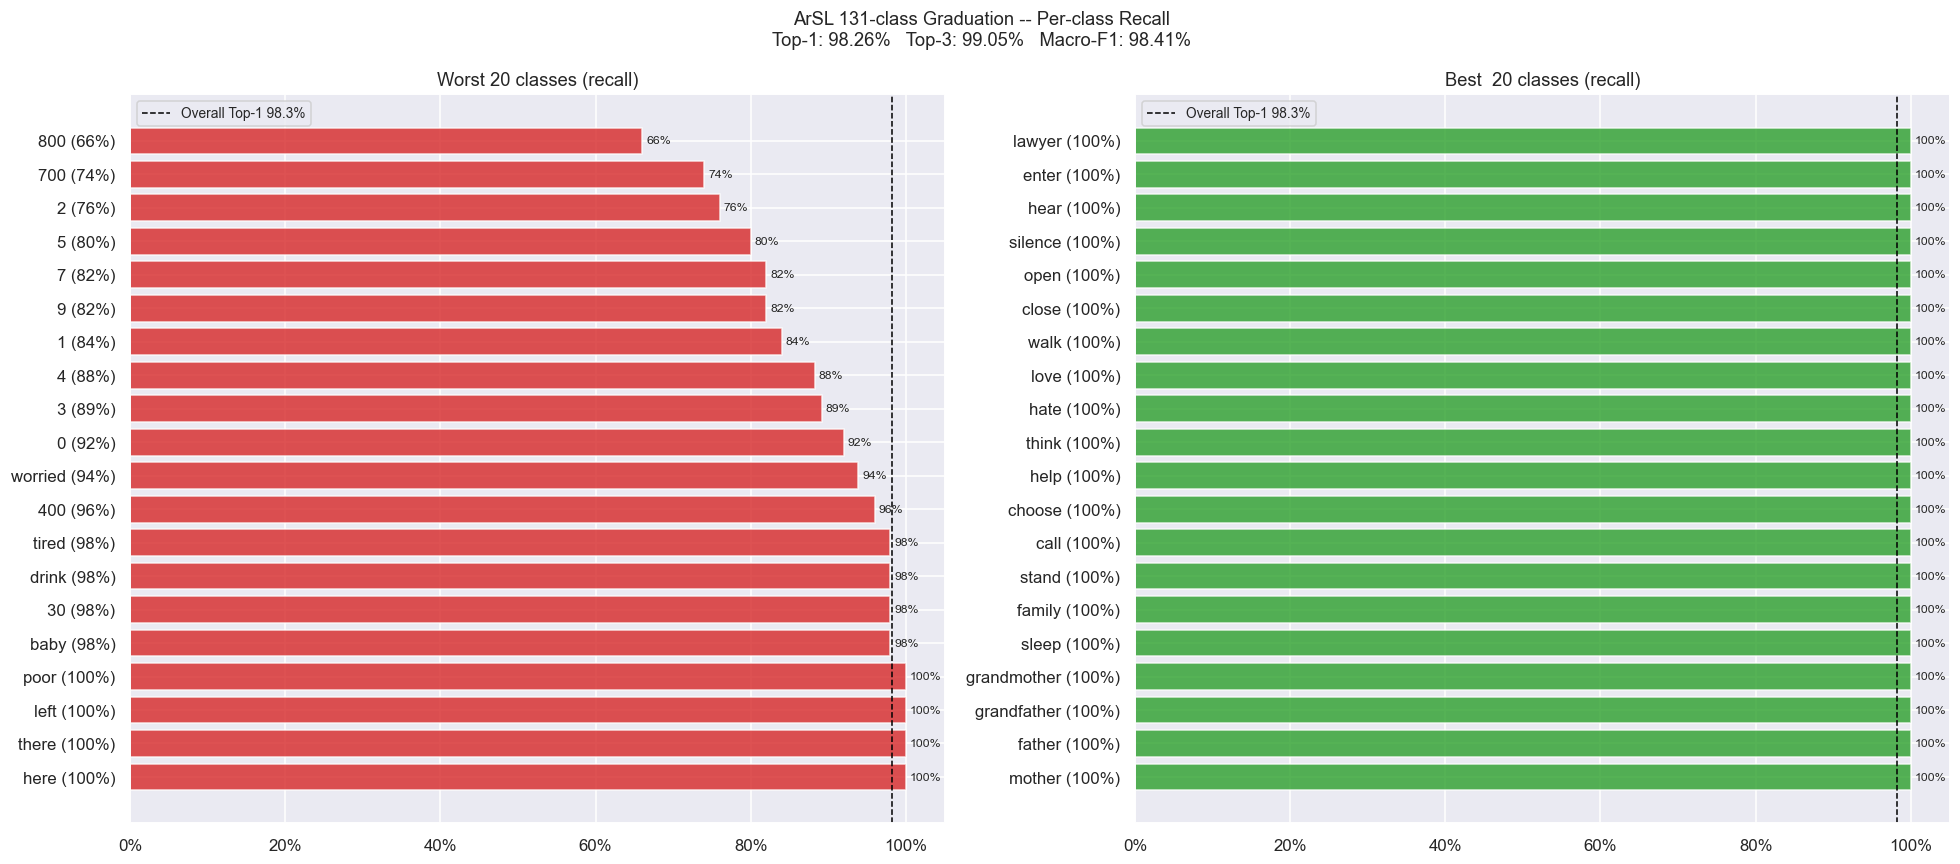

Saved: arsl_diag_per_class_bars.png

Worst 15 classes (recall):
english arabic  precision   recall  f1-score  support
    800    800   0.550000 0.660000  0.600000     50.0
    700    700   0.740000 0.740000  0.740000    100.0
      2      2   1.000000 0.760000  0.863636     50.0
      5      5   1.000000 0.800000  0.888889     50.0
      7      7   0.931818 0.820000  0.872340     50.0
      9      9   1.000000 0.820000  0.901099     50.0
      1      1   1.000000 0.840000  0.913043     50.0
      4      4   0.833333 0.882353  0.857143     17.0
      3      3   1.000000 0.891566  0.942675     83.0
      0      0   0.867925 0.920000  0.893204     50.0
worried    قلق   1.000000 0.938776  0.968421     49.0
    400    400   1.000000 0.960000  0.979592     50.0
  tired  تعبان   1.000000 0.980000  0.989899     50.0
  drink    شرب   1.000000 0.980000  0.989899     50.0
     30     30   1.000000 0.980000  0.989899     50.0


In [22]:
# Cell 7 — Worst / best classes bar chart
TOP_N = 20

worst = per_class_df.head(TOP_N).copy()
best  = per_class_df.tail(TOP_N).copy().iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, subset, title, clr in [
    (axes[0], worst, f'Worst {TOP_N} classes (recall)', '#d62728'),
    (axes[1], best,  f'Best  {TOP_N} classes (recall)', '#2ca02c'),
]:
    bar_lbls = [f"{r['english']} ({r['recall']:.0%})" for _, r in subset.iterrows()]
    vals     = subset['recall'].values.astype(float)
    bars     = ax.barh(bar_lbls, vals, color=clr, alpha=0.8)
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    ax.axvline(overall_top1, color='black', linestyle='--', linewidth=1,
               label=f'Overall Top-1 {overall_top1:.1%}')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.0%}', va='center', fontsize=8)

plt.suptitle(
    f'ArSL 131-class Graduation -- Per-class Recall\n'
    f'Top-1: {overall_top1:.2%}   Top-3: {overall_top3:.2%}   Macro-F1: {macro_f1:.2%}',
    fontsize=12
)
plt.tight_layout()
plt.savefig(str(DIR / 'arsl_diag_per_class_bars.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: arsl_diag_per_class_bars.png')

# Tabular worst-15
print('\nWorst 15 classes (recall):')
cols = ['english','arabic','precision','recall','f1-score','support']
cols = [c for c in cols if c in per_class_df.columns]
print(worst.head(15)[cols].to_string(index=False))


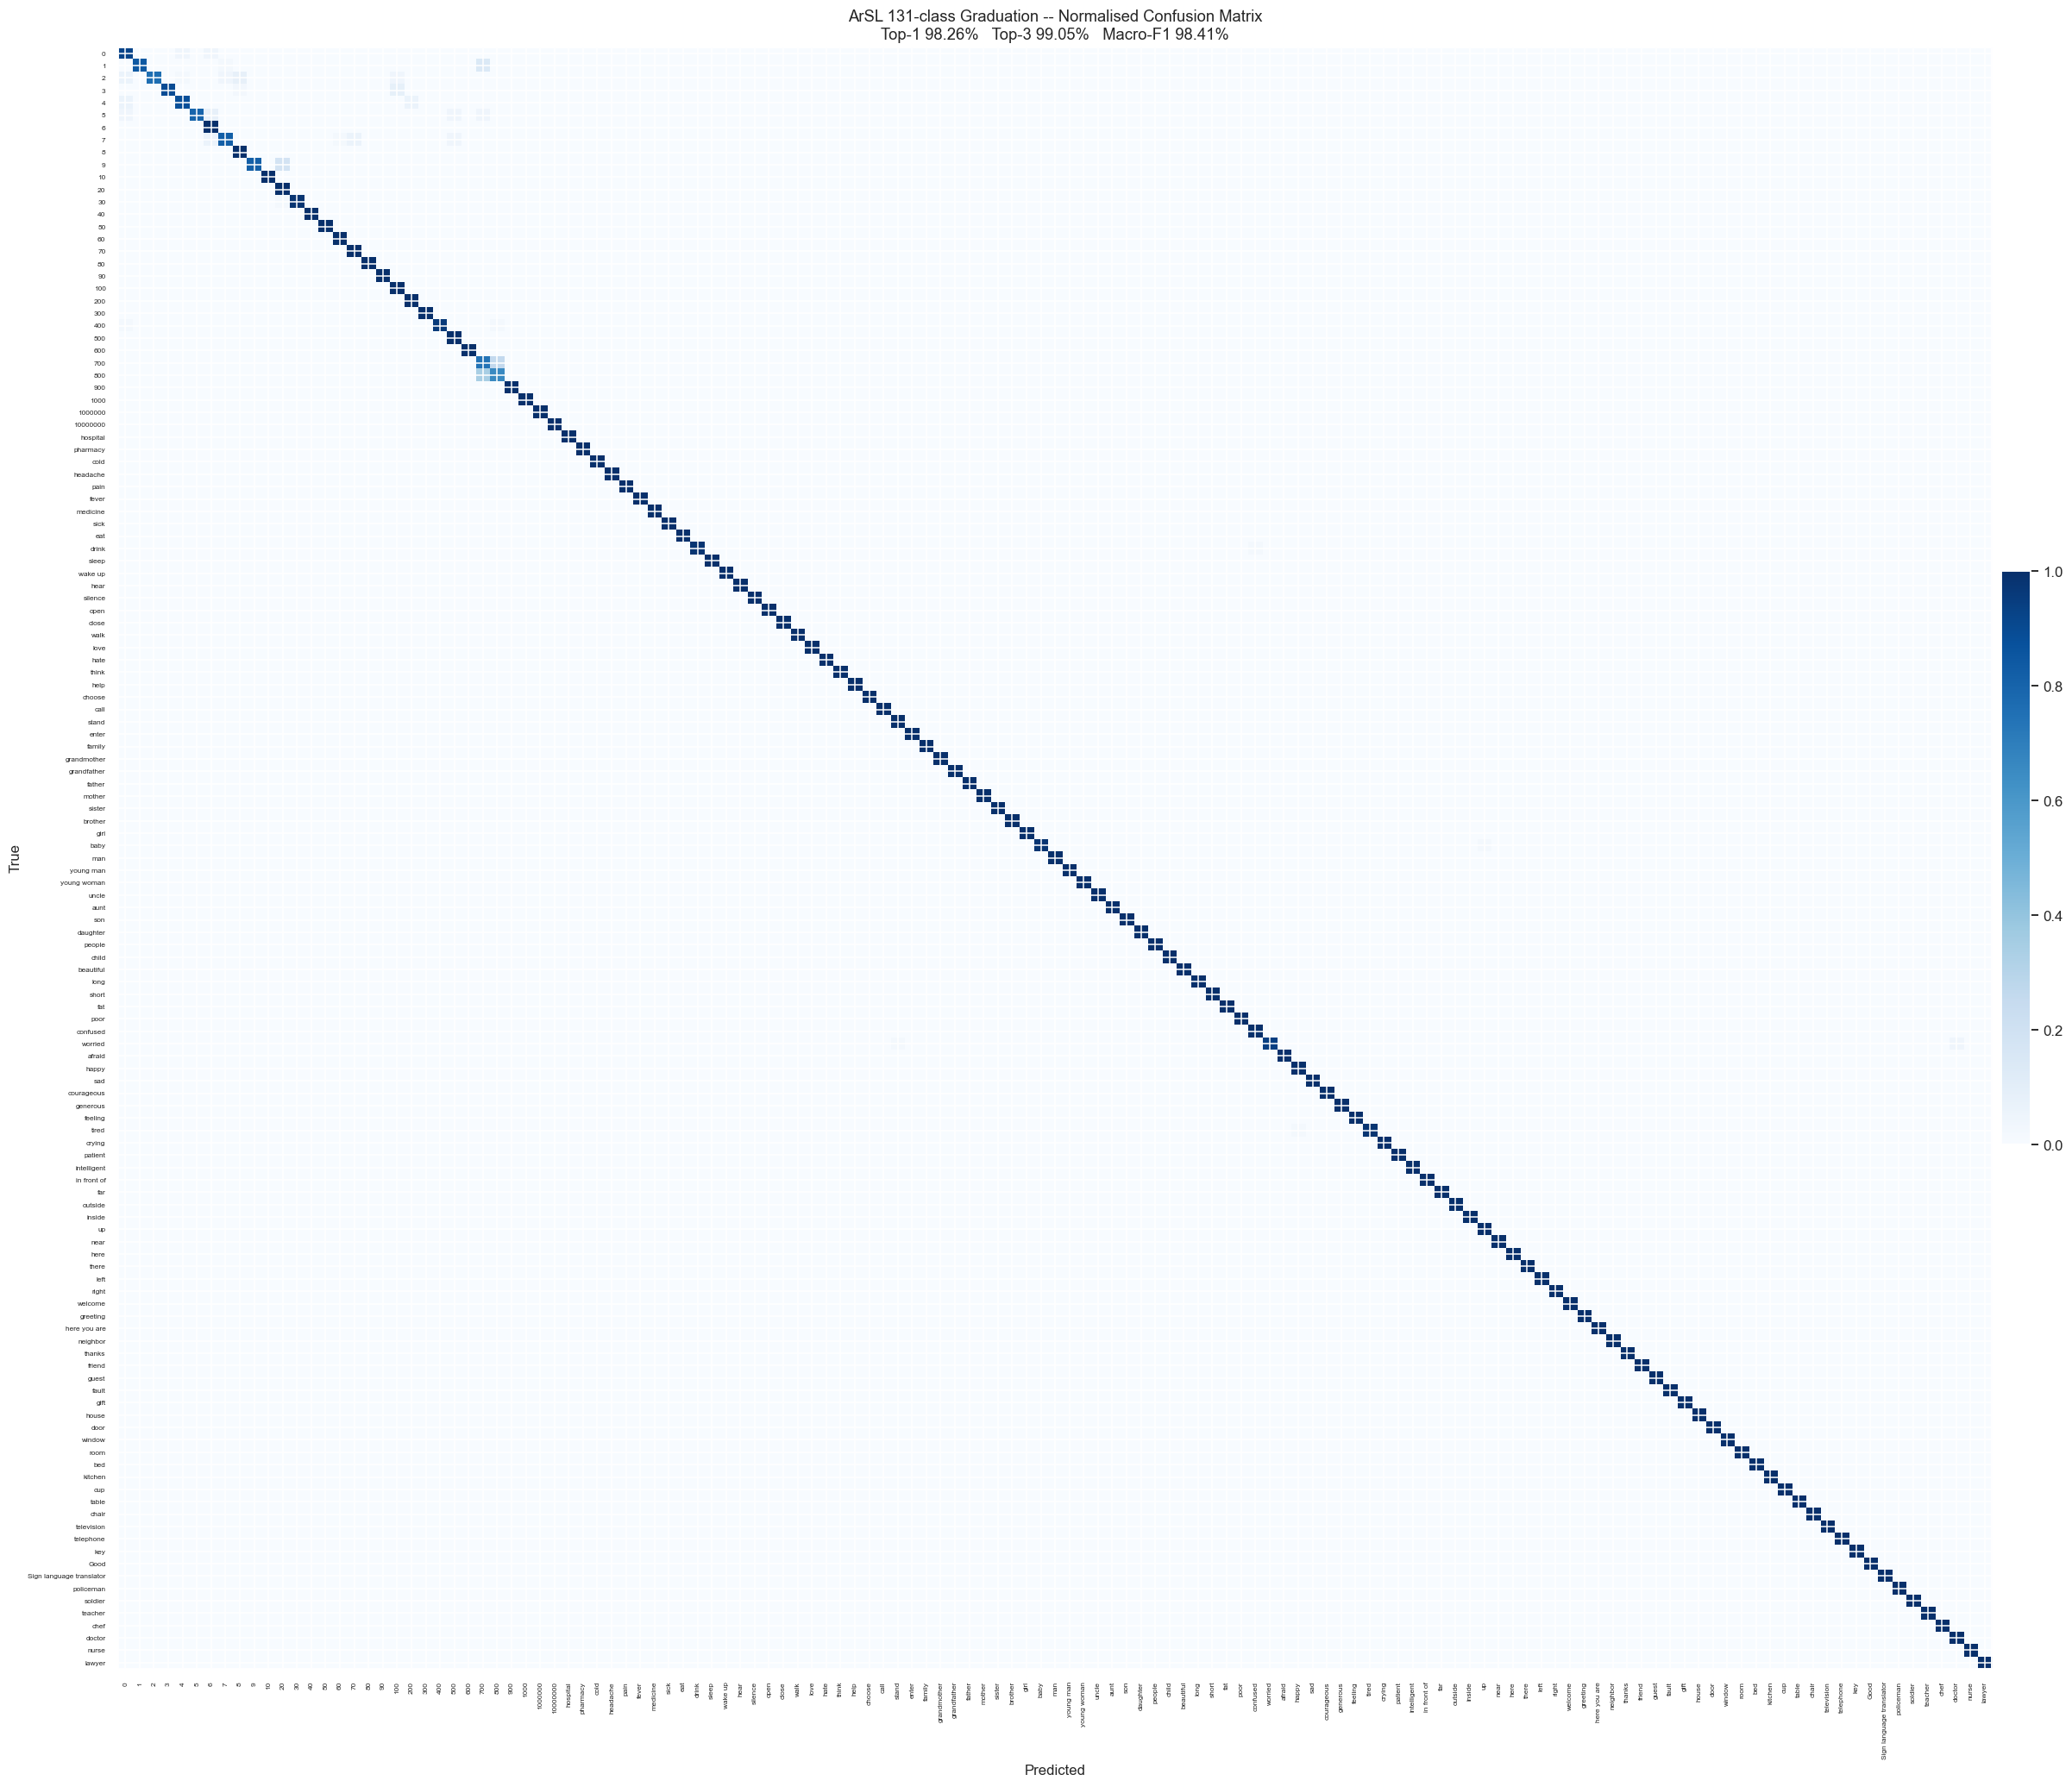

Saved: arsl_diag_confusion_matrix.png

Top-15 most frequent confusion pairs:
True                  Predicted              Count
----------------------------------------------------
700                   800                       26
800                   700                       17
9                     20                         9
1                     700                        7
3                     100                        7
2                     8                          4
5                     6                          4
2                     0                          3
7                     6                          3
7                     70                         3
0                     4                          2
5                     500                        2
2                     100                        2
2                     7                          2
worried               doctor                     2


In [23]:
# Cell 8 — Confusion matrix (normalised)
cm     = confusion_matrix(y_all, y_pred, labels=list(range(NUM_OUT)))
row_s  = cm.sum(axis=1, keepdims=True)
cm_n   = np.where(row_s > 0, cm / row_s, 0.0)

en_lbls = [idx_to_en.get(i, str(i)) for i in range(NUM_OUT)]

fig, ax = plt.subplots(figsize=(22, 19))
im = ax.imshow(cm_n, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.005)
ax.set_xticks(range(NUM_OUT))
ax.set_yticks(range(NUM_OUT))
ax.set_xticklabels(en_lbls, rotation=90, fontsize=5.5)
ax.set_yticklabels(en_lbls, fontsize=5.5)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title(
    f'ArSL 131-class Graduation -- Normalised Confusion Matrix\n'
    f'Top-1 {overall_top1:.2%}   Top-3 {overall_top3:.2%}   Macro-F1 {macro_f1:.2%}',
    fontsize=12
)
plt.tight_layout()
plt.savefig(str(DIR / 'arsl_diag_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: arsl_diag_confusion_matrix.png')

# Top confusion pairs (off-diagonal)
np.fill_diagonal(cm, 0)
flat   = cm.flatten()
top_k  = 15
top_ix = np.argsort(flat)[-top_k:][::-1]
print(f'\nTop-{top_k} most frequent confusion pairs:')
print(f'{"True":20s}  {"Predicted":20s}  {"Count":>6}')
print('-' * 52)
for ix in top_ix:
    r, c = divmod(ix, NUM_OUT)
    if flat[ix] > 0:
        print(f'{idx_to_en.get(r,str(r)):20s}  {idx_to_en.get(c,str(c)):20s}  {flat[ix]:>6.0f}')


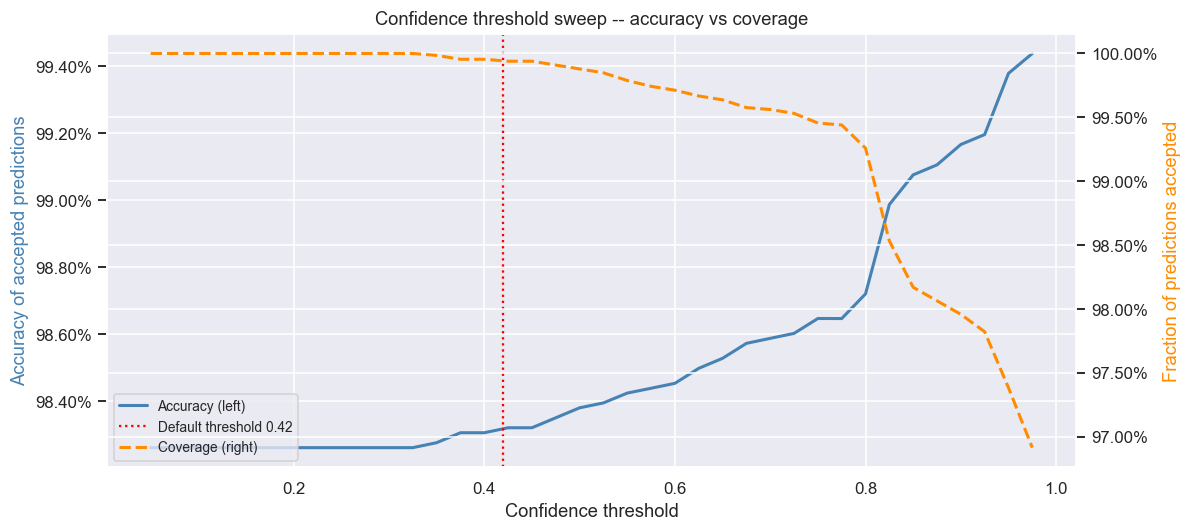

Saved: arsl_diag_threshold_sweep.png

Threshold sweep around 0.42:
 Threshold   Accuracy   Coverage
----------------------------------
     0.300      98.3%     100.0%
     0.325      98.3%     100.0%
     0.350      98.3%     100.0%
     0.375      98.3%     100.0%
     0.400      98.3%     100.0%
     0.425      98.3%      99.9% <-- default
     0.450      98.3%      99.9%
     0.475      98.4%      99.9%
     0.500      98.4%      99.9%
     0.525      98.4%      99.8%
     0.550      98.4%      99.8%
     0.575      98.4%      99.7%
     0.600      98.5%      99.7%
     0.625      98.5%      99.7%


In [24]:
# Cell 9 — Confidence threshold sweep
# Shows how accuracy and coverage change as you raise/lower the threshold.
thresholds = np.arange(0.05, 0.99, 0.025)
max_confs  = all_proba.max(axis=1)

accs, coverages = [], []
for t in thresholds:
    mask = max_confs >= t
    cov  = float(mask.mean())
    if mask.sum() > 0:
        acc = float(np.mean(y_pred[mask] == y_all[mask]))
    else:
        acc = 1.0
    accs.append(acc)
    coverages.append(cov)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, accs,      color='steelblue',  lw=2, label='Accuracy (left)')
ax2.plot(thresholds, coverages, color='darkorange', lw=2, linestyle='--', label='Coverage (right)')

ax1.axvline(0.42, color='red', linestyle=':', lw=1.5, label='Default threshold 0.42')
ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('Accuracy of accepted predictions', color='steelblue')
ax2.set_ylabel('Fraction of predictions accepted', color='darkorange')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_title('Confidence threshold sweep -- accuracy vs coverage')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig(str(DIR / 'arsl_diag_threshold_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: arsl_diag_threshold_sweep.png')

# Print table near default threshold
print(f'\nThreshold sweep around 0.42:')
print(f'{"Threshold":>10}  {"Accuracy":>9}  {"Coverage":>9}')
print('-' * 34)
for t, acc, cov in zip(thresholds, accs, coverages):
    if 0.30 <= t <= 0.65:
        marker = ' <-- default' if abs(t - 0.42) < 0.015 else ''
        print(f'{t:>10.3f}  {acc:>9.1%}  {cov:>9.1%}{marker}')


SPOTLIGHT: "headache" (class 34, Arabic: صداع)
  Samples : 50
  Top-1   : 100.0%
  Top-3   : 100.0%
  Mean conf (true class): 99.6%

  Top-10 predicted classes:
  Rank  English                 Arabic           Count     Pct
  ------------------------------------------------------------
     1  headache                صداع                50  100.0% OK


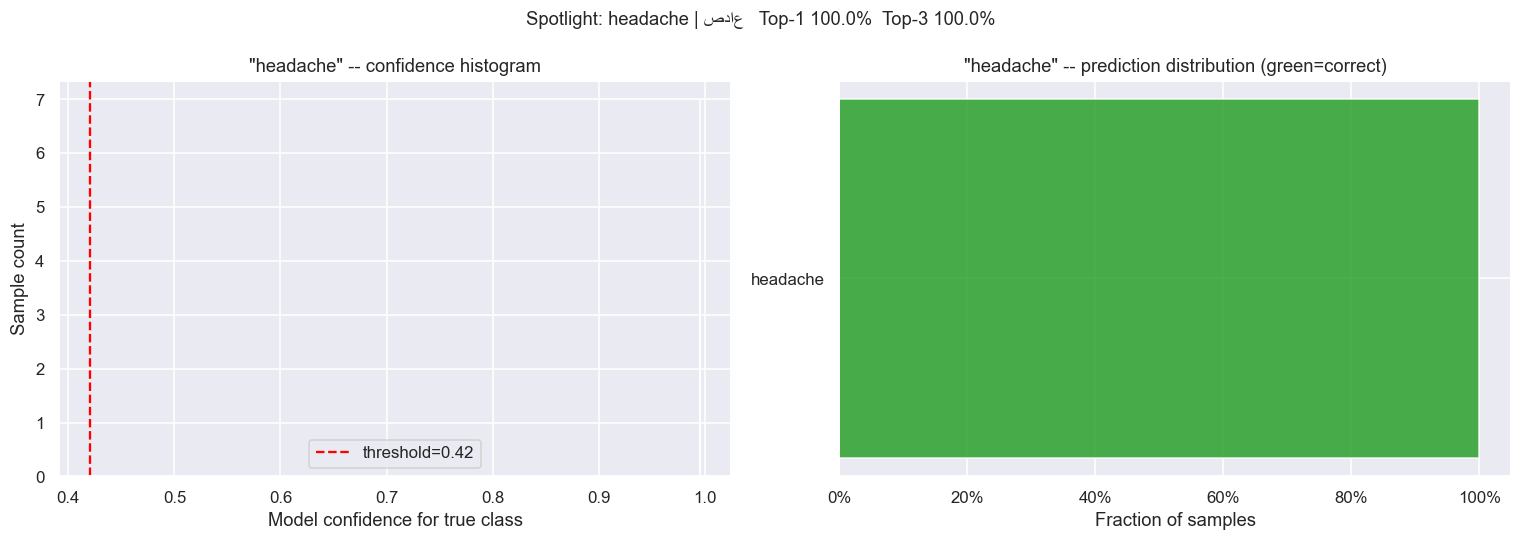

In [25]:
# Cell 10 — Single-class spotlight
# Change SPOTLIGHT_WORD to any English label in the vocabulary.
SPOTLIGHT_WORD = 'headache'
TOP_K = 10

en_to_idx = {v: k for k, v in idx_to_en.items()}

if SPOTLIGHT_WORD not in en_to_idx:
    print(f'Word "{SPOTLIGHT_WORD}" not found. Available words:')
    print(sorted(en_to_idx.keys()))
else:
    cls_idx = en_to_idx[SPOTLIGHT_WORD]
    cls_ar  = idx_to_ar.get(cls_idx, '?')
    mask    = (y_all == cls_idx)
    n_total = int(mask.sum())

    proba_cls = all_proba[mask]
    pred_cls  = y_pred[mask]

    top1_acc  = float((pred_cls == cls_idx).mean())
    top3_cls  = float(np.any(np.argsort(proba_cls, axis=1)[:, -3:] == cls_idx, axis=1).mean())
    mean_conf = float(proba_cls[:, cls_idx].mean())

    print('=' * 60)
    print(f'SPOTLIGHT: "{SPOTLIGHT_WORD}" (class {cls_idx}, Arabic: {cls_ar})')
    print('=' * 60)
    print(f'  Samples : {n_total}')
    print(f'  Top-1   : {top1_acc:.1%}')
    print(f'  Top-3   : {top3_cls:.1%}')
    print(f'  Mean conf (true class): {mean_conf:.1%}')

    # Prediction distribution
    pred_counts = defaultdict(int)
    for p in pred_cls:
        pred_counts[int(p)] += 1
    top_preds = sorted(pred_counts.items(), key=lambda x: -x[1])[:TOP_K]

    print(f'\n  Top-{TOP_K} predicted classes:')
    hdr = '  {:>4}  {:<22}  {:<14}  {:>6}  {:>6}'.format('Rank','English','Arabic','Count','Pct')
    print(hdr)
    print('  ' + '-' * 60)
    for rank, (pidx, cnt) in enumerate(top_preds, 1):
        marker = ' OK' if pidx == cls_idx else ''
        print('  {:>4}  {:<22}  {:<14}  {:>6}  {:>6.1%}{}'.format(
            rank, idx_to_en.get(pidx,'?'), idx_to_ar.get(pidx,'?'),
            cnt, cnt/n_total, marker))

    # Plots
    confs    = proba_cls[:, cls_idx]
    bar_lbls = [idx_to_en.get(p, str(p)) for p, _ in top_preds]
    bar_vals = [c / n_total for _, c in top_preds]
    bar_clrs = ['#2ca02c' if p == cls_idx else '#d62728' for p, _ in top_preds]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(confs, bins=20, color='steelblue', edgecolor='white')
    axes[0].axvline(0.42, color='red', linestyle='--', label='threshold=0.42')
    axes[0].set_xlabel('Model confidence for true class')
    axes[0].set_ylabel('Sample count')
    axes[0].set_title(f'"{SPOTLIGHT_WORD}" -- confidence histogram')
    axes[0].legend()

    axes[1].barh(bar_lbls, bar_vals, color=bar_clrs, alpha=0.85)
    axes[1].invert_yaxis()
    axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[1].set_xlabel('Fraction of samples')
    axes[1].set_title(f'"{SPOTLIGHT_WORD}" -- prediction distribution (green=correct)')

    plt.suptitle(
        f'Spotlight: {SPOTLIGHT_WORD} | {cls_ar}   '
        f'Top-1 {top1_acc:.1%}  Top-3 {top3_cls:.1%}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()
